# Import libraries

In [145]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Load data

In [110]:
user_local_dir = "/home/maxence/dev/hardware/TMS/data_processing" # Change this to your local directory

components = ["x", "y", "z"]

# Data directory
rows = ["A", "B", "C", "D", "E", "F", "G", "H"]
data_folder_dir = os.path.join(user_local_dir, f"waveforms")
data_file_paths = [os.path.join(data_folder_dir, f"{component}_component/waveform_{r}{c}_{i}.csv") for component in components for r in rows for c in range(1, 16) for i in range(1, 4)]
print(data_file_paths)
print(f"Data file paths: {data_file_paths}")

# Output directory
output_folder_dir = os.path.join(user_local_dir, "waveforms/plots")
os.makedirs(output_folder_dir, exist_ok=True)
print(f"Output folder directory: {output_folder_dir}")

['/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A1_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A1_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A1_3.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A2_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A2_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A2_3.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A3_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A3_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A3_3.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A4_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component/waveform_A4_2.csv', '/home/ma

In [111]:
data_csv = [pd.read_csv(data_file_dir) for data_file_dir in data_file_paths]
print(len(data_csv))
data_csv[0].head() 

1080


,Time (s),Voltage (V)
0,0.00,0.098
1,0.04,0.108
2,0.08,0.102
3,0.12,0.112
4,0.16,0.104


# Plot Rx Voltage Map

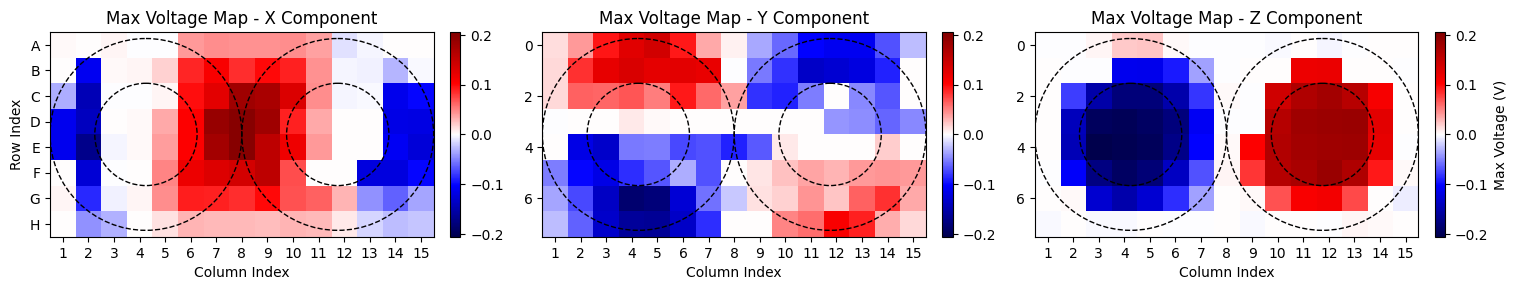

In [146]:
max_voltages = np.array([data_csv[i]['Voltage (V)'][5:][np.argmax(np.abs((data_csv[i]['Voltage (V)'][5:])))] for i in range(len(data_csv))])
max_voltages = max_voltages.reshape(3, 8, 15, 3)
max_voltages_mean = max_voltages.mean(axis=3)

absolute_max = np.max(np.abs(max_voltages_mean))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

y_center = 3.5
x_left = 3.25
x_right = 10.75
r_out = 3.75
r_in = 2.0

for i, component in enumerate(components):
    axes[i].imshow(max_voltages_mean[i], cmap='seismic', vmin=-absolute_max, vmax=absolute_max)
    axes[i].set_title(f'Max Voltage Map - {component.capitalize()} Component')
    axes[i].set_xlabel('Column Index')
    axes[i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    
    # add colorbar
    cbar = plt.colorbar(axes[i].imshow(max_voltages_mean[i], cmap='seismic', vmin=-absolute_max, vmax=absolute_max), ax=axes[i], fraction=0.025, pad=0.04)

    axes[i].add_patch(Circle((x_left, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_left, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

    axes[i].add_patch(Circle((x_right, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_right, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))


cbar.set_label('Max Voltage (V)')

axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
axes[0].set_ylabel('Row Index')

plt.show()

# Plot B-field Map

In [101]:
# We used a 1cm diameter self wounded coil.
area = np.pi * (0.01 / 2) ** 2 # in m^2
print(f"Area of Rx coil: {area} m^2")

N_turns = 10

NAeff = N_turns * area
print(f"N*A of Rx coil: {NAeff} m^2")

Area of Rx coil: 7.853981633974483e-05 m^2
N*A of Rx coil: 0.0007853981633974482 m^2


In [134]:
max_b_field = -max_voltages_mean / NAeff

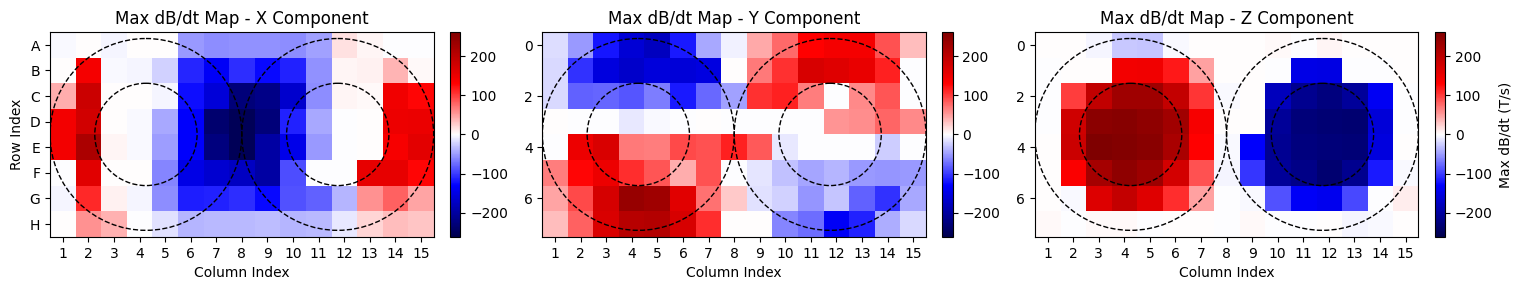

In [ ]:

absolute_max = np.max(np.abs(max_b_field))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

y_center = 3.5
x_left = 3.25
x_right = 10.75
r_out = 3.75
r_in = 2.0

for i, component in enumerate(components):
    axes[i].imshow(max_b_field[i], cmap='seismic', vmin=-absolute_max, vmax=absolute_max)
    axes[i].set_title(f'Max dB/dt Map - {component.capitalize()} Component')
    axes[i].set_xlabel('Column Index')
    axes[i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    
    # add colorbar
    cbar = plt.colorbar(axes[i].imshow(max_b_field[i], cmap='seismic', vmin=-absolute_max, vmax=absolute_max), ax=axes[i], fraction=0.025, pad=0.04)

    axes[i].add_patch(Circle((x_left, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_left, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

    axes[i].add_patch(Circle((x_right, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_right, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

cbar.set_label('Max dB/dt (T/s)')

axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
axes[0].set_ylabel('Row Index')

plt.show()

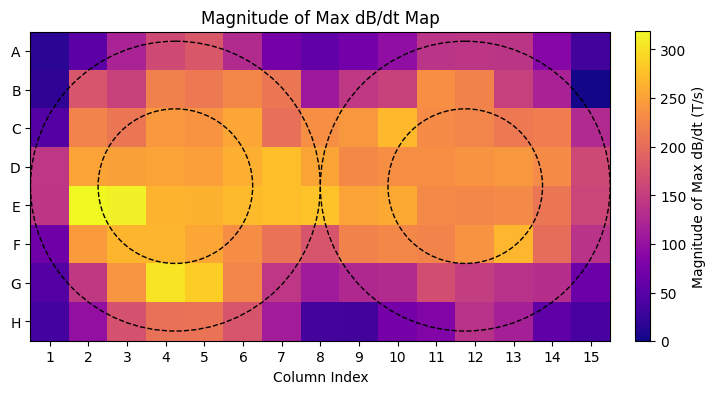

In [147]:
# plot magnitude of dB/dt
max_b_field_magnitude = np.linalg.norm(max_b_field, axis=0)
absolute_max = np.max(max_b_field_magnitude)

plt.figure(figsize=(8, 6))
plt.imshow(max_b_field_magnitude, cmap='plasma', vmin=0, vmax=absolute_max)
plt.title('Magnitude of Max dB/dt Map')
plt.xlabel('Column Index')
plt.xticks(ticks=np.arange(15), labels=np.arange(1, 16))
plt.yticks(ticks=np.arange(len(rows)), labels=rows)
cbar = plt.colorbar(fraction=0.025, pad=0.04)
cbar.set_label('Magnitude of Max dB/dt (T/s)')

ax = plt.gca()

ax.add_patch(Circle((x_left, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
ax.add_patch(Circle((x_left, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

ax.add_patch(Circle((x_right, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
ax.add_patch(Circle((x_right, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

plt.show()

# Plot E-field Map